# 🎯 Clustering - Perfiles de Empleados EBLET v2.0

## Objetivo
Identificar perfiles naturales de empleados usando K-Means.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

import os
import sys
RAIZ_PROYECTO = r"C:\Users\torre\OneDrive\Escritorio\EBLET-People-Analytics\Python"
sys.path.insert(0, os.path.join(RAIZ_PROYECTO, "src"))

ESCENARIOS = ["saludable", "estable", "riesgo_burnout", "riesgo_boreout", "critico"]
dfs = {}
for esc in ESCENARIOS:
    ruta = os.path.join(RAIZ_PROYECTO, f"datasets/{esc}/empleados.csv")
    df = pd.read_csv(ruta)
    df["escenario"] = esc
    dfs[esc] = df  # ← AÑADIR ESTA LÍNEA

df_all = pd.concat(dfs.values(), ignore_index=True)
print(f"✅ Dataset cargado: {len(df_all):,} empleados")
df_all = pd.concat(dfs.values(), ignore_index=True)
print(f"✅ Dataset cargado: {len(df_all):,} empleados")

✅ Dataset cargado: 12,500 empleados
✅ Dataset cargado: 12,500 empleados


## 1. Preparación de Datos

In [3]:
features_cluster = [
    "kpi_burnout", "kpi_boreout", "kpi_bienestar", 
    "kpi_rotacion", "kpi_contexto",
    "edad", "experiencia", "antiguedad"
]

df_cluster = df_all[features_cluster].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f"✅ Matriz de clustering: {X_scaled.shape}")

✅ Matriz de clustering: (12500, 8)


## 2. Análisis de Silueta

k=2: Silhouette=0.307
k=3: Silhouette=0.262
k=4: Silhouette=0.246
k=5: Silhouette=0.269
k=6: Silhouette=0.275
k=7: Silhouette=0.280
k=8: Silhouette=0.283
k=9: Silhouette=0.271
k=10: Silhouette=0.274


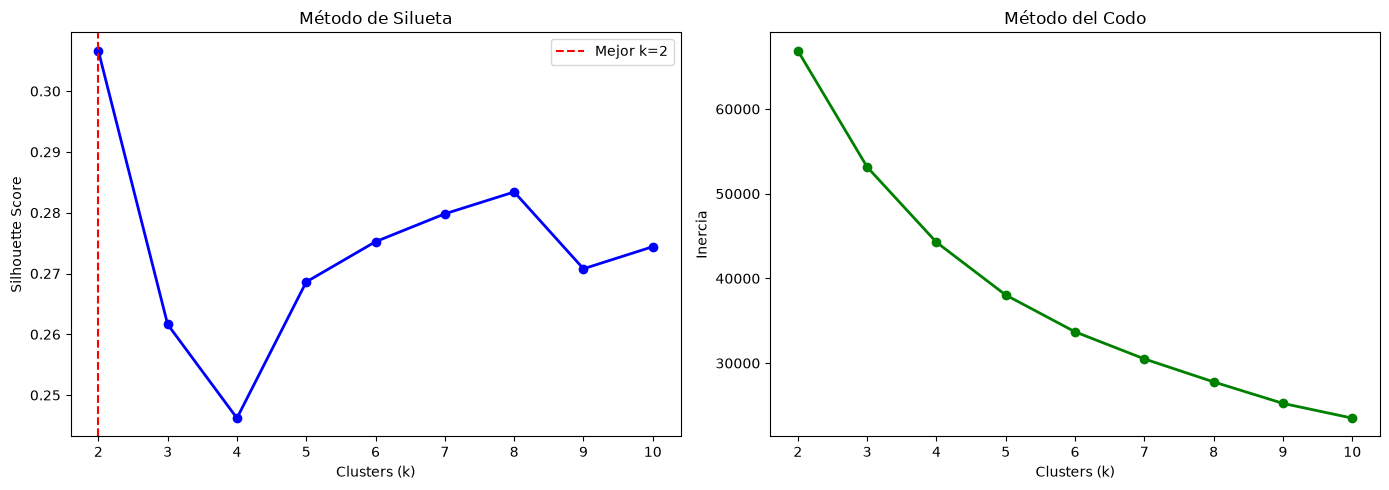


🎯 k óptimo: 2


In [4]:
K_range = range(2, 11)
silhouettes = []
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels))
    inertias.append(km.inertia_)
    print(f"k={k}: Silhouette={silhouette_score(X_scaled, labels):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), silhouettes, 'bo-', linewidth=2)
best_k = list(K_range)[np.argmax(silhouettes)]
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
axes[0].set_xlabel("Clusters (k)")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Método de Silueta")
axes[0].legend()

axes[1].plot(list(K_range), inertias, 'go-', linewidth=2)
axes[1].set_xlabel("Clusters (k)")
axes[1].set_ylabel("Inercia")
axes[1].set_title("Método del Codo")

plt.tight_layout()
plt.show()

print(f"\n🎯 k óptimo: {best_k}")

## 3. Clustering Final

In [5]:
K_FINAL = 6

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_cluster["cluster"] = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_cluster["pca1"] = X_pca[:, 0]
df_cluster["pca2"] = X_pca[:, 1]

fig = px.scatter(
    df_cluster,
    x="pca1", y="pca2",
    color="cluster",
    title=f"🗺️ Visualización 2D de Clusters (PCA) - k={K_FINAL}",
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(height=600)
fig.show()

print(f"\n📊 Distribución:")
print(df_cluster["cluster"].value_counts().sort_index())


📊 Distribución:
cluster
0    1894
1    2555
2    2086
3    1970
4    2002
5    1993
Name: count, dtype: int64


## 4. Caracterización de Clusters

In [6]:
kpis_cluster = ["kpi_burnout", "kpi_boreout", "kpi_bienestar", 
                "kpi_rotacion", "kpi_contexto"]

perfil_kpis = df_cluster.groupby("cluster")[kpis_cluster].mean().round(2)

print("="*70)
print("PERFILES KPI POR CLUSTER")
print("="*70)
print(perfil_kpis)

fig = px.imshow(
    perfil_kpis,
    color_continuous_scale='RdYlGn_r',
    zmin=1, zmax=5,
    title="🔥 Perfil de KPIs por Cluster",
    aspect='auto',
    text_auto='.2f'
)
fig.update_layout(height=400)
fig.show()

PERFILES KPI POR CLUSTER
         kpi_burnout  kpi_boreout  kpi_bienestar  kpi_rotacion  kpi_contexto
cluster                                                                     
0               4.68         4.20           1.73          4.88          1.84
1               2.40         1.94           4.04          3.02          3.83
2               2.38         1.88           4.09          2.96          3.89
3               3.84         3.24           2.12          4.42          2.21
4               1.96         4.19           2.38          3.96          2.34
5               4.36         1.75           2.38          4.24          2.42


## 5. Etiquetado Semántico

In [7]:
def etiquetar_cluster(row):
    b = row["kpi_burnout"]
    bo = row["kpi_boreout"]
    w = row["kpi_bienestar"]
    r = row["kpi_rotacion"]
    
    if b >= 3.5 and bo >= 3.5:
        return "🔴 Crítico Dual"
    elif b >= 3.5 and bo < 3.0:
        return "🟠 Quemado Activo"
    elif b < 3.0 and bo >= 3.5:
        return "🔵 Desconectado"
    elif b < 2.5 and bo < 2.5 and w > 3.5:
        return "🟢 Thriving"
    elif r > 3.5 and w < 3.0:
        return "⚫ Vuelo Inminente"
    else:
        return "🟡 Estable Neutro"

perfil_kpis["etiqueta"] = perfil_kpis.apply(etiquetar_cluster, axis=1)

print("="*70)
print("ETIQUETAS DE CLUSTERS")
print("="*70)
for cluster_id, row in perfil_kpis.iterrows():
    print(f"\nCluster {cluster_id}: {row['etiqueta']}")

cluster_to_label = perfil_kpis["etiqueta"].to_dict()
df_cluster["perfil"] = df_cluster["cluster"].map(cluster_to_label)

ETIQUETAS DE CLUSTERS

Cluster 0: 🔴 Crítico Dual

Cluster 1: 🟢 Thriving

Cluster 2: 🟢 Thriving

Cluster 3: ⚫ Vuelo Inminente

Cluster 4: 🔵 Desconectado

Cluster 5: 🟠 Quemado Activo


## 📝 Conclusiones

Los clusters revelan perfiles naturales que trascienden los escenarios predefinidos.